In [5]:
import pandas as pd

In [6]:
business_df = pd.read_csv('business.csv')
economy_df = pd.read_csv('economy.csv')
clean_dataset_df = pd.read_csv('Clean_Dataset.csv')

In [ ]:
print("Business Dataset:")
print(business_df.head())
print("\nBusiness Dataset Info:")
business_df.info()

Business Dataset:
         date    airline ch_code  num_code dep_time   from time_taken  \
0  11-02-2022  Air India      AI       868    18:00  Delhi    02h 00m   
1  11-02-2022  Air India      AI       624    19:00  Delhi    02h 15m   
2  11-02-2022  Air India      AI       531    20:00  Delhi    24h 45m   
3  11-02-2022  Air India      AI       839    21:25  Delhi    26h 30m   
4  11-02-2022  Air India      AI       544    17:15  Delhi    06h 40m   

                                                stop arr_time      to   price  
0                                          non-stop     20:00  Mumbai  25,612  
1                                          non-stop     21:15  Mumbai  25,612  
2  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...    20:45  Mumbai  42,220  
3  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...    23:55  Mumbai  44,450  
4  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...    23:55  Mumbai  46,690  

Business Dataset Info:
<class 'pandas.core.frame.DataFrame'>
R

In [8]:
print("\nEconomy Dataset:")
print(economy_df.head())
print("\nEconomy Dataset Info:")
economy_df.info()


Economy Dataset:
         date   airline ch_code  num_code dep_time   from time_taken  \
0  11-02-2022  SpiceJet      SG      8709    18:55  Delhi    02h 10m   
1  11-02-2022  SpiceJet      SG      8157    06:20  Delhi    02h 20m   
2  11-02-2022   AirAsia      I5       764    04:25  Delhi    02h 10m   
3  11-02-2022   Vistara      UK       995    10:20  Delhi    02h 15m   
4  11-02-2022   Vistara      UK       963    08:50  Delhi    02h 20m   

        stop arr_time      to  price  
0  non-stop     21:05  Mumbai  5,953  
1  non-stop     08:40  Mumbai  5,953  
2  non-stop     06:35  Mumbai  5,956  
3  non-stop     12:35  Mumbai  5,955  
4  non-stop     11:10  Mumbai  5,955  

Economy Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     

In [12]:
print("\nClean Dataset:")
print(clean_dataset_df.head())
print("\nClean Dataset Info:")
clean_dataset_df.info()


Clean Dataset:
   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  

Clean Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):

In [14]:
df = pd.read_csv('Clean_Dataset.csv')

# Borramos las columnas que no aportan valor 
# Unnamed: 0 es un índice y flight tiene demasiados valores únicos
df = df.drop(['Unnamed: 0', 'flight'], axis=1)

# Convertir la variable 'price' en categórica
# Dividiremos los precios en bajo, medio y alto
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Bajo', 'Medio', 'Alto'])
df = df.drop('price', axis=1)

# Usaremos one-hot encoding para las variables categóricas restantes.
df = pd.get_dummies(df, columns=['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class'], drop_first=True)

In [15]:
print("DataFrame Preprocesado:")
print(df.head())
print("\nDataFrame Preprocesado Info:")
df.info()

DataFrame Preprocesado:
   duration  days_left price_category  airline_Air_India  airline_GO_FIRST  \
0      2.17          1          Medio              False             False   
1      2.33          1          Medio              False             False   
2      2.17          1          Medio              False             False   
3      2.25          1          Medio              False             False   
4      2.33          1          Medio              False             False   

   airline_Indigo  airline_SpiceJet  airline_Vistara  source_city_Chennai  \
0           False              True            False                False   
1           False              True            False                False   
2           False             False            False                False   
3           False             False             True                False   
4           False             False             True                False   

   source_city_Delhi  ...  arrival_time_Even

In [ ]:
df.to_csv('Datos_procesados.csv', index=False)
print("\nDataFrame preprocesado guardado como 'Datos_procesados.csv'")

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X = df.drop('price_category', axis=1)
y = df['price_category']

random_seed = 1234
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed, stratify=y)

scaler = StandardScaler()
X_train['duration'] = scaler.fit_transform(X_train[['duration']])
X_test['duration'] = scaler.transform(X_test[['duration']])

# Modelo lineal discriminante
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

print("Resultados del Análisis Discriminante Lineal (LDA)")
accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"Accuracy: {accuracy_lda:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lda))

In [17]:
# Modelo lineal discriminante
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

print("Resultados del Análisis Discriminante Lineal (LDA)")
accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"Accuracy: {accuracy_lda:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lda))

Resultados del Análisis Discriminante Lineal (LDA)
Accuracy: 0.8043

Classification Report:
              precision    recall  f1-score   support

        Alto       1.00      0.93      0.97     30014
        Bajo       0.75      0.72      0.73     30018
       Medio       0.69      0.76      0.72     30014

    accuracy                           0.80     90046
   macro avg       0.81      0.80      0.81     90046
weighted avg       0.81      0.80      0.81     90046




Matriz de Confusión:


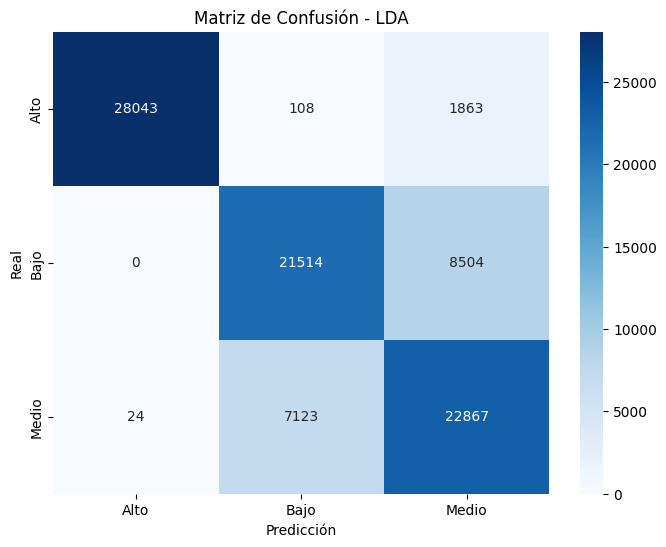

In [18]:
# Matriz de confusión
print("\nMatriz de Confusión:")
cm_lda = confusion_matrix(y_test, y_pred_lda)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', xticklabels=lda.classes_, yticklabels=lda.classes_)
plt.title('Matriz de Confusión - LDA')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

Resultados del Análisis Discriminante Lineal (LDA)
Accuracy: 0.8050

Classification Report:
              precision    recall  f1-score   support

        Alto       1.00      0.93      0.96     30014
        Bajo       0.75      0.72      0.73     30018
       Medio       0.69      0.76      0.72     30014

    accuracy                           0.81     90046
   macro avg       0.81      0.81      0.81     90046
weighted avg       0.81      0.81      0.81     90046


Matriz de Confusión:
              precision    recall  f1-score   support

        Alto       1.00      0.93      0.96     30014
        Bajo       0.75      0.72      0.73     30018
       Medio       0.69      0.76      0.72     30014

    accuracy                           0.81     90046
   macro avg       0.81      0.81      0.81     90046
weighted avg       0.81      0.81      0.81     90046


Matriz de Confusión:


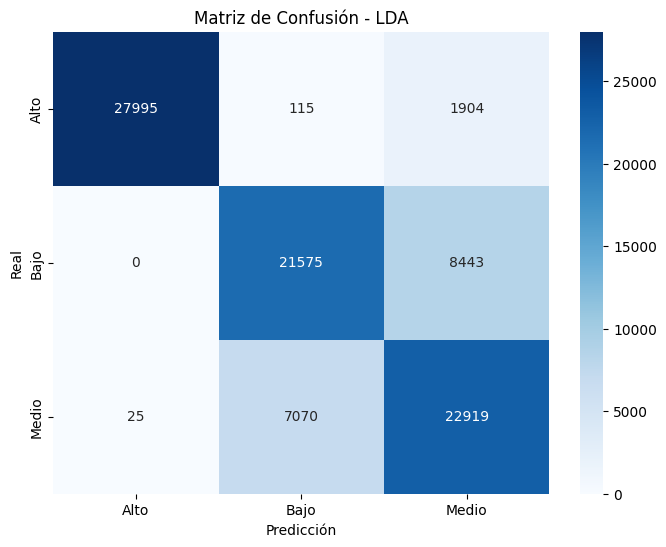

In [ ]:
# 1. Preparar los datos
X = df.drop('price_category', axis=1)
y = df['price_category']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Estandarizar las características
# Solo estandarizamos la columna 'duration' que es la única numérica no binaria
scaler = StandardScaler()
X_train['duration'] = scaler.fit_transform(X_train[['duration']])
X_test['duration'] = scaler.transform(X_test[['duration']])

# 3. Entrenar el modelo LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 4. Realizar predicciones
y_pred_lda = lda.predict(X_test)

# 5. Evaluar el modelo
print("Resultados del Análisis Discriminante Lineal (LDA)")
accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"Accuracy: {accuracy_lda:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lda))

# Matriz de confusión
print("\nMatriz de Confusión:")
cm_lda = confusion_matrix(y_test, y_pred_lda)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', xticklabels=lda.classes_, yticklabels=lda.classes_)
plt.title('Matriz de Confusión - LDA')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()